libraries

In [22]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [23]:
import numpy as np

X_train_scaled = np.load("X_train_scaled.npy")
X_test_scaled = np.load("X_test_scaled.npy")
y_train = np.load("y_train.npy")
y_test = np.load("y_test.npy")
X_train_normal = np.load("X_train_normal.npy")

print(X_train_scaled.shape)
print(X_train_normal.shape)

(22544, 116)
(9711, 116)


autoencoder base

In [24]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

def build_autoencoder(input_dim, learning_rate=0.001, dropout_rate=0.2):
    """
    Builds an improved Autoencoder model for anomaly detection in network traffic.
    
    Improvements:
    - Added Dropout layers for regularization to reduce overfitting and false positives.
    - Added BatchNormalization for training stability and faster convergence.
    - Configurable learning rate with Adam optimizer.
    - Compiled with MSE loss and additional MAE metric for better reconstruction evaluation.
    - Wrapped in a function for modularity and reusability (e.g., for hyperparameter tuning).
    - Suggested callbacks for training (EarlyStopping and ReduceLROnPlateau) to prevent overfitting
      and improve efficiency, aligning with project goals of reliable detection and reduced false alarms.
    
    Args:
        input_dim (int): Number of input features (e.g., 41 for NSL-KDD dataset).
        learning_rate (float): Learning rate for the optimizer.
        dropout_rate (float): Dropout rate for regularization.
    
    Returns:
        Model: Compiled Keras Autoencoder model.
    """
    # Input layer
    input_layer = Input(shape=(input_dim,), name='input_features')
    
    # Encoder
    encoded = Dense(32, activation='relu', name='encoder_dense_1')(input_layer)
    encoded = BatchNormalization(name='encoder_bn_1')(encoded)
    encoded = Dropout(dropout_rate, name='encoder_dropout_1')(encoded)
    
    encoded = Dense(16, activation='relu', name='encoder_dense_2')(encoded)
    encoded = BatchNormalization(name='encoder_bn_2')(encoded)
    encoded = Dropout(dropout_rate, name='encoder_dropout_2')(encoded)
    
    latent = Dense(8, activation='relu', name='latent_space')(encoded)
    
    # Decoder (symmetric to encoder)
    decoded = Dense(16, activation='relu', name='decoder_dense_1')(latent)
    decoded = BatchNormalization(name='decoder_bn_1')(decoded)
    decoded = Dropout(dropout_rate, name='decoder_dropout_1')(decoded)
    
    decoded = Dense(32, activation='relu', name='decoder_dense_2')(decoded)
    decoded = BatchNormalization(name='decoder_bn_2')(decoded)
    decoded = Dropout(dropout_rate, name='decoder_dropout_2')(decoded)
    
    # Output layer for reconstruction
    output_layer = Dense(input_dim, activation='linear', name='reconstructed_features')(decoded)
    
    # Model definition
    autoencoder = Model(inputs=input_layer, outputs=output_layer, name='hybrid_nids_autoencoder')
    
    # Compile with improved optimizer and metrics
    optimizer = Adam(learning_rate=learning_rate)
    autoencoder.compile(
        optimizer=optimizer,
        loss='mse',
        metrics=['mae']  # Mean Absolute Error as additional reconstruction metric
    )
    
    return autoencoder

# Example usage (assuming X_train_normal is prepared from NSL-KDD or CICIDS2017)
# input_dim = X_train_normal.shape[1]  # e.g., 41 for NSL-KDD
# model = build_autoencoder(input_dim)

# Optional: Training callbacks for better performance (use during fit())
# callbacks = [
#     EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
#     ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
# ]

# # Train on normal traffic only
# history = model.fit(
#     X_train_normal, X_train_normal,
#     epochs=100,
#     batch_size=32,
#     validation_split=0.2,
#     callbacks=callbacks,
#     verbose=1
# )

# Display model summary
# model.summary()

In [25]:
input_dim = X_train_normal.shape[1]

autoencoder = build_autoencoder(input_dim)

autoencoder.summary()

Model: "hybrid_nids_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_features (InputLayer)     │ (None, 116)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_1 (Dense)         │ (None, 32)             │         3,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_bn_1                    │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dropout_1 (Dropout)     │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_2 (Dense)         │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_bn_2                    │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dropout_2 (Dropout)     │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_1 (Dense)         │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_bn_1                    │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dropout_1 (Dropout)     │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_2 (Dense)         │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_bn_2                    │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dropout_2 (Dropout)     │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstructed_features (Dense)  │ (None, 116)            │         3,828 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,308 (36.36 KB)

 Trainable params: 9,116 (35.61 KB)

 Non-trainable params: 192 (768.00 B)

In [26]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

history = autoencoder.fit(
    X_train_normal,
    X_train_normal,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.6155 - mae: 0.3455 - val_loss: 0.2053 - val_mae: 0.1189 - learning_rate: 0.0010
Epoch 2/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4359 - mae: 0.1731 - val_loss: 0.1696 - val_mae: 0.0765 - learning_rate: 0.0010
Epoch 3/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4136 - mae: 0.1290 - val_loss: 0.1583 - val_mae: 0.0664 - learning_rate: 0.0010
Epoch 4/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4031 - mae: 0.1086 - val_loss: 0.1558 - val_mae: 0.0626 - learning_rate: 0.0010
Epoch 5/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3972 - mae: 0.0993 - val_loss: 0.1546 - val_mae: 0.0610 - learning_rate: 0.0010
Epoch 6/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3926 - mae: 0.0937 - val_loss: 0.1495 - val_mae: 0.0573 - learning_rate: 0.0010
Epoch 7/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3891 - mae: 0.0900 - val_loss: 0.1511 - val_mae: 0.0593 - learning_rate: 0.0010

checking reconstruction rate

In [27]:
reconstructions = autoencoder.predict(X_test_scaled)
# Test dataset (25192 rows)
#Split into batches (~32 rows)
#Run each batch through autoencoder
#Generate reconstructed output
#Return reconstructed dataset
mse = np.mean(np.power(X_test_scaled - reconstructions, 2), axis=1)

788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


threshold

In [28]:
threshold = np.percentile(mse, 95)

print("Threshold:", threshold)

Threshold: 8.96211010272889


In [29]:
y_pred_ae = (mse > threshold).astype(int)

In [30]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_ae))

              precision    recall  f1-score   support

           0       0.56      0.99      0.71     13449
           1       0.88      0.09      0.17     11743

    accuracy                           0.57     25192
   macro avg       0.72      0.54      0.44     25192
weighted avg       0.71      0.57      0.46     25192



error distribution graph

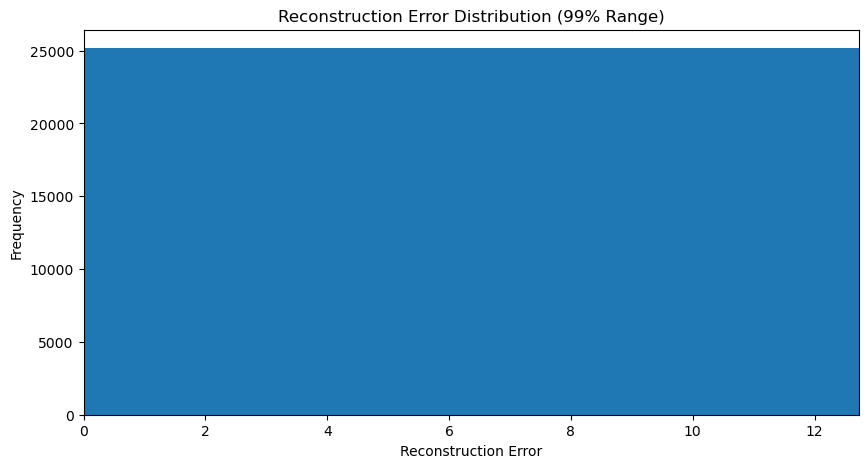

In [31]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.hist(mse, bins=50)
plt.xlim(0, np.percentile(mse, 99))  # remove extreme outliers
plt.title("Reconstruction Error Distribution (99% Range)")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.show()

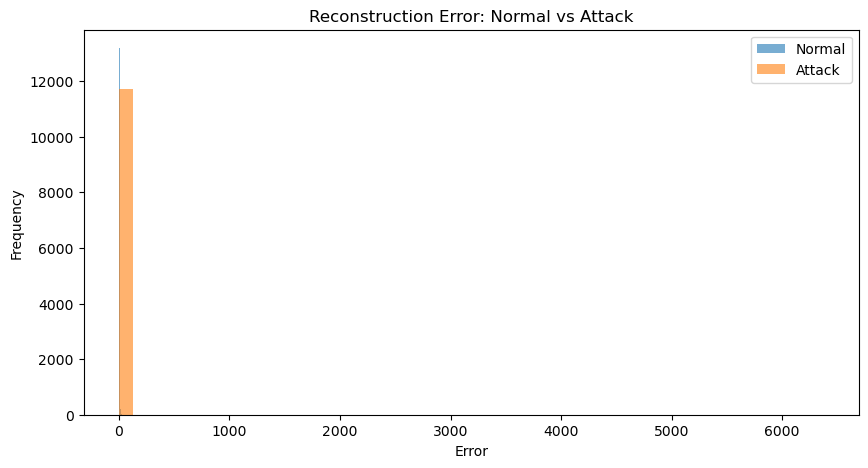

In [32]:
import pandas as pd
error_df = pd.DataFrame({
    "reconstruction_error": mse,
    "true_label": y_test
})

plt.figure(figsize=(10,5))

plt.hist(error_df[error_df.true_label==0].reconstruction_error,
         bins=50, alpha=0.6, label="Normal")

plt.hist(error_df[error_df.true_label==1].reconstruction_error,
         bins=50, alpha=0.6, label="Attack")

plt.legend()
plt.title("Reconstruction Error: Normal vs Attack")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

auto encodeer reaches
| Metric                      | Meaning                                       |
| --------------------------- | --------------------------------------------- |
| Normal Recall = **0.97**    | Model detects normal traffic very well        |
| Attack Recall = **0.18**    | Model misses most attacks                     |
| Attack Precision = **0.84** | When it predicts attack, it’s usually correct |
good at low false positives weak at recall


Isolation Forest starts

learns statistical anomalies

In [33]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.1,
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_train_scaled)

IsolationForest(contamination=0.1, n_estimators=200, n_jobs=-1, random_state=42)

scores

In [34]:
if_scores = iso_forest.decision_function(X_test_scaled)

# convert to anomaly score
if_scores = -if_scores

normalizing both scores (ae+if)

In [35]:
from sklearn.preprocessing import MinMaxScaler

ae_scaler = MinMaxScaler()
if_scaler = MinMaxScaler()

ae_norm = ae_scaler.fit_transform(mse.reshape(-1,1)).flatten()
if_norm = if_scaler.fit_transform(if_scores.reshape(-1,1)).flatten()

HYBRID SCORING

In [36]:
alpha = 0.6 # weight for Autoencoder score

hybrid_score = alpha * ae_norm + (1 - alpha) * if_norm

hybrid threshold

In [37]:
import numpy as np

threshold = np.percentile(hybrid_score, 75)

y_pred_hybrid = (hybrid_score > threshold).astype(int)

evaluation of hybrid ids

In [38]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, hybrid_score)

optimal_idx = np.argmax(tpr - fpr)
threshold = thresholds[optimal_idx]

y_pred_hybrid = (hybrid_score > threshold).astype(int)

print(classification_report(y_test, y_pred_hybrid))
print(confusion_matrix(y_test, y_pred_hybrid))

              precision    recall  f1-score   support

           0       0.89      0.82      0.85     13449
           1       0.81      0.88      0.85     11743

    accuracy                           0.85     25192
   macro avg       0.85      0.85      0.85     25192
weighted avg       0.85      0.85      0.85     25192

[[11064  2385]
 [ 1403 10340]]


Predicted
Actual     Normal  Attack
Normal        TN      FP
Attack        FN      TP
Term	Meaning
TN	correct normal prediction
FP	false alarm
FN	missed attack
TP	correctly detected attack

In [39]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_hybrid).ravel()

fpr = fp / (fp + tn)

print("False Positive Rate:", fpr)

False Positive Rate: 0.17733660495204104


In [40]:
autoencoder.save("../models/autoencoder.h5")

In [41]:
import joblib

joblib.dump(iso_forest, "../models/isolation_forest.pkl")

['../models/isolation_forest.pkl']